# **Clustering Prestador y Tareas Unificado Variational Autoencoder con KMeans**


# 1 - Librerías

In [42]:
from google.cloud import bigquery
import bigframes.pandas as bpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import re
from bigframes.ml.preprocessing import StandardScaler
from bigframes.ml.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Lambda, Layer
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K
from tensorflow.keras.losses import mse
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split

# 2 - Carga de Datos

In [43]:
# Objecto cliente

client = bigquery.Client()

In [44]:
# sql_engine: bigquery
# output_variable: data_proc
# output_mode: table
# start _sql
_sql = """
SELECT * FROM proyecto-sura-clustering-2026.sura_clustering_cleaned.unified_dataset;
""" # end _sql
from google.colab.sql import bigquery as _bqsqlcell
data_proc = _bqsqlcell.run(_sql)
data_proc

,NMCANTIDAD_PEDIDA,NMCANTIDAD_EJECUTADA,PTVALOR_TAREA,CAPACIDAD,CLASIFICACION_ADMINISTRATIVA,CLASIFICACION_ASESORÍA,CLASIFICACION_CAPACITACIÓN,CLASIFICACION_EXAMEN,CLASIFICACION_LUDICO,CLASIFICACION_MATERIALES,...,CIUDAD_MANIZALES,CIUDAD_MEDELLIN,CIUDAD_PEREIRA,MACRO_DSBLOQUE_DESEMPEÑO HUMANO,MACRO_DSBLOQUE_EMERGENCIAS,MACRO_DSBLOQUE_ESPECIALIZADOS,MACRO_DSBLOQUE_ESTRATEGIA Y CAMBIO,MACRO_DSBLOQUE_EVENTOS,MACRO_DSBLOQUE_GENERAL Y OTROS,MACRO_DSBLOQUE_PREVENCION
0,1.325873,0.884943,0.241389,-4.678781,False,True,False,False,False,False,...,False,True,False,True,False,False,False,False,False,False
1,0.705458,0.178867,-0.125214,0.014318,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,1.263831,-0.106568,-0.125214,-0.623332,False,True,False,False,False,False,...,False,True,False,False,False,False,False,False,True,False
3,0.441782,-0.106568,-0.125214,-0.113212,False,True,False,False,False,False,...,False,True,False,False,False,False,False,False,True,False
4,-0.163122,-0.106568,-0.125214,0.907027,False,True,False,False,False,False,...,False,True,False,False,True,False,False,False,False,False
5,-0.194143,-0.106568,-0.125214,0.907027,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
6,-0.194143,-0.106568,-0.125214,-4.678781,False,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
7,-0.008019,-0.106568,-0.125214,0.396907,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
8,-0.163122,-0.106568,-0.125214,0.907027,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
9,-0.170878,-0.106568,-0.125214,0.907027,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [45]:
# Limpiar las columnas

def limpiar_nombre_columna(columna):

    columna = columna.replace('Á', 'A').replace('É', 'E').replace('Í', 'I').replace('Ó', 'O').replace('Ú', 'U')
    columna = columna.replace('á', 'a').replace('é', 'e').replace('í', 'i').replace('ó', 'o').replace('ú', 'u')
    columna = columna.replace('Ñ', 'N').replace('ñ', 'n').replace('Ü', 'U').replace('ü', 'u')
    columna = re.sub(r'[^a-zA-Z0-9_]', '_', columna)

    return columna

nuevas_columnas = [limpiar_nombre_columna(col) for col in data_proc.columns]
data_proc.columns = nuevas_columnas

# 3 - VAE

In [46]:
data_proc_pd = data_proc.to_pandas().astype('float32')

# Partir los datos en training y testing sets

X_train, X_test = train_test_split(data_proc_pd, test_size = 0.2, random_state = 42)

# Definir los parámetros del VAE

original_dim = X_train.shape[1]
intermediate_dim = 256
latent_dim = 12

# ==========================================
# 1. ENCODER
# ==========================================

inputs = Input(shape = (original_dim,))
h = Dense(intermediate_dim, activation = 'relu')(inputs)
z_mean = Dense(latent_dim)(h)
z_log_var = Dense(latent_dim)(h)

# Reparametrizacion

def sampling(args):

    z_mean, z_log_var = args
    epsilon = K.random_normal(shape=(tf.shape(z_mean)[0], latent_dim), mean = 0., stddev = 1.)

    return z_mean + K.exp(z_log_var / 2) * epsilon

z = Lambda(sampling, output_shape=(latent_dim,))([z_mean, z_log_var])

# ==========================================
# 2. DECODER
# ==========================================

decoder_h = Dense(intermediate_dim, activation = 'relu')
decoder_outputs = Dense(original_dim, activation = 'linear')
h_decoded = decoder_h(z)
outputs = decoder_outputs(h_decoded)

# ==========================================
# 3. CAPA DE PÉRDIDA PERSONALIZADA
# ==========================================

class VAELossLayer(Layer):

    def __init__(self, original_dim, **kwargs):

        super().__init__(**kwargs)

        self.original_dim = original_dim

    def call(self, inputs, outputs, z_mean, z_log_var):

        reconstruction_loss = mse(inputs, outputs)
        reconstruction_loss *= self.original_dim

        z_log_var_safe = tf.clip_by_value(z_log_var, clip_value_min = -10.0, clip_value_max = 10.0)

        kl_loss = 1 + z_log_var_safe - tf.math.square(z_mean) - tf.math.exp(z_log_var_safe)
        kl_loss = tf.reduce_sum(kl_loss, axis = -1)
        kl_loss *= -0.5

        vae_loss = tf.reduce_mean(reconstruction_loss + kl_loss)

        self.add_loss(vae_loss)
        return outputs

# ==========================================
# 4. ENSAMBLAJE DEL MODELO VAE
# ==========================================

outputs = VAELossLayer(original_dim)(inputs, outputs, z_mean, z_log_var)

vae = Model(inputs, outputs)
optimizador_seguro = Adam(learning_rate = 0.01, clipnorm = 1.0)
vae.compile(optimizer=optimizador_seguro)


# Entrenar

vae.fit(X_train, X_train, epochs = 100, batch_size = 4096, validation_data = (X_test, X_test))


# ==========================================
# 5. EXTRACCIÓN Y PREDICCIÓN
# ==========================================

# Modelo encoder --> espacio latente definido

encoder = Model(inputs, z_mean)

# Transformar el dataset original con el encoder

data_reduced_vae = encoder.predict(data_proc_pd, batch_size = 1024)

# Convertir a DataFrame

data_reduced_vae_df = pd.DataFrame(data_reduced_vae, columns = [f'vae_feature_{i + 1}' for i in range(latent_dim)])

Epoch 1/100
302/302 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 5.9287 - val_loss: 5.2907
Epoch 2/100
302/302 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 9626.5332 - val_loss: 5.1285
Epoch 3/100
302/302 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 5.0946 - val_loss: 5.0754
Epoch 4/100
302/302 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 5.0834 - val_loss: 5.0411
Epoch 5/100
302/302 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 5.1292 - val_loss: 5.1564
Epoch 6/100
302/302 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 5.1774 - val_loss: 5.1567
Epoch 7/100
302/302 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 5.1009 - val_loss: 5.0393
Epoch 8/100
302/302 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 5.0410 - val_loss: 5.0091
Epoch 9/100
302/302 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 5.0642 - val_loss: 5.1078
Epoch 10/100
302/302 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 5.2251 - val_loss: 5.0793
Epoch 11/100
302/302 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 5.2006 - val_loss: 5.0501
Epoch 12/100
302/302 ━━━━━━

In [47]:
# Definimos la cantidad de clusters

NUM_CLUSTERS = 4

print(f"Entrenando K-Means con {NUM_CLUSTERS} clusters sobre el espacio latente del VAE...")

kmeans_vae = KMeans(n_clusters = NUM_CLUSTERS)

# Entrenar y predecir usand data_reduced_vae_df

clusters_vae = kmeans_vae.fit_predict(data_reduced_vae_df)

# Asignar los resultados a la tabla original

data_proc['CLUSTER_ASIGNADO_VAE'] = clusters_vae['CENTROID_ID'].tolist()

print("¡Clustering completado y asignado a la tabla maestra!")

Entrenando K-Means con 4 clusters sobre el espacio latente del VAE...


¡Clustering completado y asignado a la tabla maestra!


In [48]:
# Ver cuántos registros quedaron en cada cluster

tamano_clusters_vae = data_proc.groupby('CLUSTER_ASIGNADO_VAE').size().to_pandas()

print("\n--- TAMAÑO DE LOS NUEVOS CLUSTERS ---")

display(tamano_clusters_vae)


--- TAMAÑO DE LOS NUEVOS CLUSTERS ---


,0
CLUSTER_ASIGNADO_VAE,
1,280
2,1530350
3,398
4,11681


In [49]:
# Evaluacion


# Davies-Bouldin

db_score = davies_bouldin_score(data_reduced_vae_df, clusters_vae['CENTROID_ID'].to_pandas())

print(f"2. Davies-Bouldin Score: {db_score:.4f}")

# Calinski-Harabasz

ch_score = calinski_harabasz_score(data_reduced_vae_df, clusters_vae['CENTROID_ID'].to_pandas())

print(f"3. Calinski-Harabasz Score: {ch_score:,.2f}")

# 3. SILHOUETTE SCORE mediante muestreo

# Muestra aleatoria para la silueta

muestra_df = data_reduced_vae_df.sample(n = 100000, random_state = 42)

# Extraer las etiquetas de los clusters
clusters_vae_pandas_series = clusters_vae['CENTROID_ID'].to_pandas()
muestra_labels = clusters_vae_pandas_series[muestra_df.index]

sil_score = silhouette_score(muestra_df, muestra_labels)

print(f"4. Silhouette Score (Muestra): {sil_score:.4f}")

2. Davies-Bouldin Score: 0.9501


3. Calinski-Harabasz Score: 30,060.27


4. Silhouette Score (Muestra): 0.5510


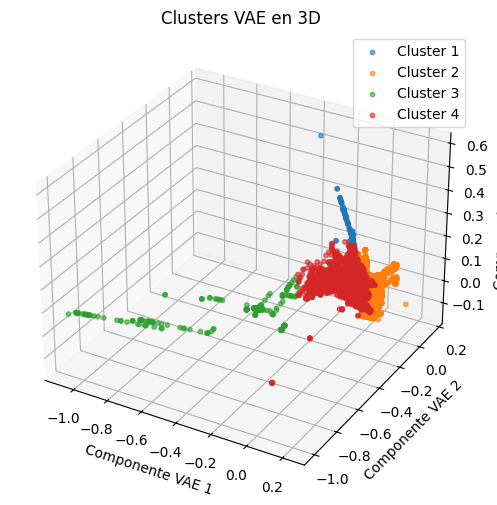

In [50]:
# Grafica en 3D de los 3 clusters

num_components_3d = min(3, latent_dim)

if num_components_3d < 3:

    data_3d = data_reduced_vae_df.iloc[:, :num_components_3d]

else:

    data_3d = data_reduced_vae_df.iloc[:, :3]

# Crear la figura y los ejes 3D

fig = plt.figure(figsize = (8, 6))
ax = fig.add_subplot(111, projection = '3d')

# Obtener las etiquetas de los clusters

cluster_labels = data_proc['CLUSTER_ASIGNADO_VAE'].to_pandas()

# Graficar cada cluster

for cluster_id in sorted(cluster_labels.unique()):

    cluster_data = data_3d[cluster_labels == cluster_id]

    ax.scatter(cluster_data.iloc[:, 0], cluster_data.iloc[:, 1], cluster_data.iloc[:, 2],
               label = f'Cluster {cluster_id}', alpha = 0.6, s = 10)

# Configurar etiquetas y título

ax.set_xlabel('Componente VAE 1')
ax.set_ylabel('Componente VAE 2')
ax.set_zlabel('Componente VAE 3')
ax.set_title('Clusters VAE en 3D')
ax.legend()
plt.show()